In [3]:
import sys
import os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor
processor = LogProcessor('../../logs/nothing_bot@07_04_2025_1300.log')
processor.read_log()

In [14]:
df = processor.activities_log.copy()
df = df[df['product']=='SQUID_INK']
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

In [83]:
mm_bid_vol = df.apply(lambda row: max(row[[f"bid_volume_{i}" for i in range(1,4)]].fillna(0)), axis=1)
mm_ask_vol = df.apply(lambda row: max(row[[f"ask_volume_{i}" for i in range(1,4)]].fillna(0)), axis=1)
ratio = mm_bid_vol-mm_ask_vol

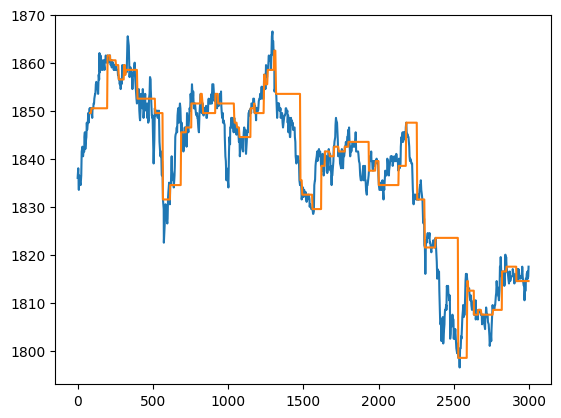

In [93]:
plt.plot(df.mid_price)
lim = 4
plt.plot((df.mid_price*(abs(ratio)>lim)).replace(0,np.nan).ffill())

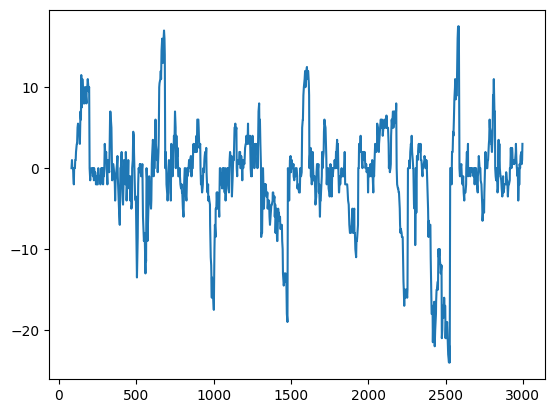

In [94]:
plt.plot(df.mid_price-(df.mid_price*(abs(ratio)>lim)).replace(0,np.nan).ffill())

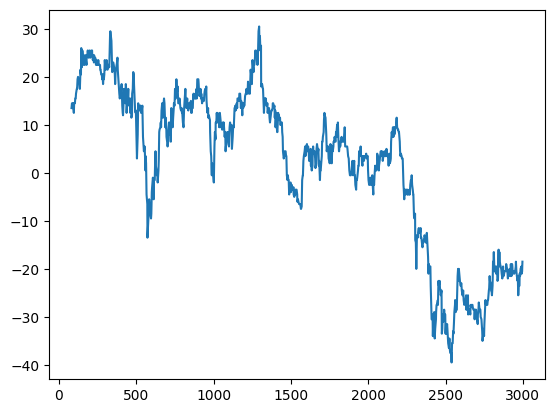

In [95]:
pos = (((ratio)>lim).astype(int) + (ratio<-lim).astype(int)).replace(0,np.nan).ffill()
plt.plot(pos*df.mid_price.diff().cumsum())